# Sensitivitätsanalyse Patagonien

In [1]:
import os
import papermill as pm
import pandas as pd
import numpy as np  

# ==========================================
# Anzahl der Modelle zwischen upper und lower bound
# num_runs = 5 -> 5 Schritte inkl. lower & upper bound (3 Zwischenwerte)
num_runs = 10
# ==========================================

# Werte und Grenzen aus Excel einlesen
df = pd.read_excel("Sensitivitäten.xlsx", sheet_name="Datenauswahl", decimal=',')
df.set_index("Variable", inplace=True)

# Struktur für Ergebnis laden
df_mc = pd.read_excel("Sensitivitäten.xlsx", sheet_name="Ergebnisse", engine="openpyxl")

# Modellpfade
model_dir = os.path.abspath(os.path.join("..", "Ammoniak_Greenfield_Patagonien"))
notebook_path = os.path.join(model_dir, "Modell_Ammoniak_Greenfield_Patagonien.ipynb")

#Papermill schreibt das Ergebnis-Notebook dorthin
trash_path = "trash_output.ipynb"

# Laufzähler über alle Variablen hinweg
run_counter = 0

# Schleife über alle Variablen (Zeilen in df)
for var in df.index:
    low = df.loc[var, "lower bound"]
    high = df.loc[var, "upper bound"]

    # Linear interpolierte Werte zwischen low und high (inkl. Grenzen)
    values = np.linspace(low, high, num_runs)

    print(f"Variable: {var} ({low} → {high}, {num_runs} Schritte)")

    # Für diese Variable num_runs Modelle rechnen
    for value in values:
        run_counter += 1
        run_name = f"Run_{run_counter}"
        print(f"Starte {run_name} für Variable '{var}' mit Wert {value:.2f}")

        # overrides: nur EIN Wert (eine Variable)
        overrides = {var: round(float(value), 2)}

        # Notebook ausführen mit overrides
        pm.execute_notebook(
            notebook_path,
            output_path=trash_path,
            parameters={"overrides": overrides},
            cwd=model_dir
        )
        os.remove(trash_path)

        # Ergebnis einlesen
        ergebnisse_path = os.path.join(model_dir, "Ergebnisse.csv")
        Ergebnisse_df = pd.read_csv(ergebnisse_path, sep=';', decimal=',')
        Ergebnisse_df.set_index("Variable", inplace=True)
        Ergebnisse = Ergebnisse_df["Wert"].to_dict()

        # Neue Spalte in df_mc anlegen
        if run_name not in df_mc.columns:
            df_mc[run_name] = None

        # Input (übersteuerte Variable) eintragen
        for v, val in overrides.items():
            df_mc.loc[df_mc["Variable"] == v, run_name] = val

        # Outputs eintragen
        for v, val in Ergebnisse.items():
            df_mc.loc[df_mc["Variable"] == v, run_name] = val

        # Zahlen erzwingen
        df_mc[run_name] = pd.to_numeric(df_mc[run_name], errors="coerce")

        print(f"{run_name} abgeschlossen.")

# Finale Ausgabe
df_mc.to_csv("Sensitivität_Ergebnisse.csv", sep=";", encoding="utf-8-sig", decimal=',', index=False)
print("Export abgeschlossen → Sensitivität_Ergebnisse.csv")


Passed unknown parameter: overrides
Input notebook does not contain a cell with tag 'parameters'


Variable: zinssatz_pem (0.02 → 0.4, 10 Schritte)
Starte Run_1 für Variable 'zinssatz_pem' mit Wert 0.02


Executing:   0%|          | 0/148 [00:00<?, ?cell/s]

Passed unknown parameter: overrides
Input notebook does not contain a cell with tag 'parameters'


Run_1 abgeschlossen.
Starte Run_2 für Variable 'zinssatz_pem' mit Wert 0.06


...

Executing:   0%|          | 0/148 [00:00<?, ?cell/s]

Passed unknown parameter: overrides
Input notebook does not contain a cell with tag 'parameters'


Run_69 abgeschlossen.
Starte Run_70 für Variable 'zinssatz_wkaon' mit Wert 0.29


Executing:   0%|          | 0/148 [00:00<?, ?cell/s]

Run_70 abgeschlossen.
Export abgeschlossen → Sensitivität_Ergebnisse.csv


# Darstellung der Ergebnisse

## Farben

In [2]:
col_n2 = col_asu = "#e5742e"                # Corporate orange              oder Gas orange: "#e4932c"
col_pv = "#e4cb3a"                          # PV Gelb
col_wka = "#128fcf"                         # WKA Blau
col_h2 = col_pem = "#14689b"                # Corporate Blau                oder Wasser blau: "#1b5aa6"
col_nh3 = col_hb = "#822181"                # Corporate Lila                oder Fern/Nahwärme Lila: "#8f2f89"
col_h2s = "#79CADD"                         #Corporate Hellblau Alternativ: Stromsektor Rot  #E02229             bzw Gasspeicher rot
col_bat = "#8CBF3E"                         # ElChem Speicher grün
col_buy = "#505050"
col_chem = "#1D9838"              # Biomasse Grün
col_etc = "#828282"                         # Corporate Grau

col_co2 = col_mea = col_dac = "#050505"               # Diesel grau
col_saf = col_ft = "#c796c4"                # Coorporate lila blass
col_ch4 = col_mg = "#e4932c"           
col_el= col_sell = "#E02229"                # Stromsektor Rot
col_q = col_hp = "#B01920"                  # Dunkelrot (Geothermie rot) 
col_qs = "#B96428"                          # Braunkohle braun
col_naph = "#DADADA"                        # Coorporate grau blass
col_bio = "#C796C4"                         # Coorporate Lila blass

col_ch3oh = col_ms = "#e5742e"              # Gas orange  

## Funktion

In [3]:
import matplotlib.pyplot as plt

def plot_sensitivity(
    df_params: pd.DataFrame,
    df_mc: pd.DataFrame,
    metric_name: str,
    save_path: str | None = None,
):
    """
    Plottet Sensitivitätslinien für alle in df_params enthaltenen Variablen.
    Nutzt definierte Farben aus df_params["Farbe"].
    """

    # alle Run_-Spalten
    run_cols = [c for c in df_mc.columns if c.startswith("Run_")]
    if not run_cols:
        raise ValueError("Keine Run_-Spalten in df_mc gefunden.")

    # Outputzeile holen
    metric_row = df_mc.loc[df_mc["Variable"] == metric_name, run_cols]
    if metric_row.empty:
        raise ValueError(f"Metrik '{metric_name}' nicht in df_mc['Variable'] gefunden.")
    metric_row = metric_row.iloc[0].astype(float)

    fig, ax = plt.subplots()

    # Iteration über alle Parameter
    for var in df_params.index:

        # Parameterwerte (Overrides)
        param_row = df_mc.loc[df_mc["Variable"] == var, run_cols]
        if param_row.empty:
            continue

        param_row = param_row.iloc[0].astype(float)
        mask = param_row.notna()
        if mask.sum() == 0:
            continue

        # Linie-X-Werte
        x_values = param_row[mask].values.astype(float)

        # Baseline → 0%
        baseline = float(df_params.loc[var, "Wert"])
        x_percent = (x_values - baseline) / baseline * 100.0

        # Linie-Y-Werte
        y_values = metric_row[mask].values.astype(float)

        # Farbe holen → Spalte "Farbe" enthält z. B. "col_h2preis"
        color_varname = df_params.loc[var, "Farbe"]

        try:
            color_hex = globals()[color_varname]
        except KeyError:
            raise KeyError(
                f"Die Farbe '{color_varname}' ist nicht im Notebook definiert. "
            )

        # Plotten
        ax.plot(
            x_percent,
            y_values,
            marker="o",
            linestyle="-",
            linewidth=2.0,
            label=var,
            color=color_hex,
        )

    ax.set_xlabel("Prozent anhand eines Basevalue [%]")
    ax.set_ylabel(metric_name)
    ax.set_title("Sensitivität der Parameter")
    ax.grid(True, which="both", linestyle=":")

    ax.legend()

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300)

    return fig, ax


## Aufruf

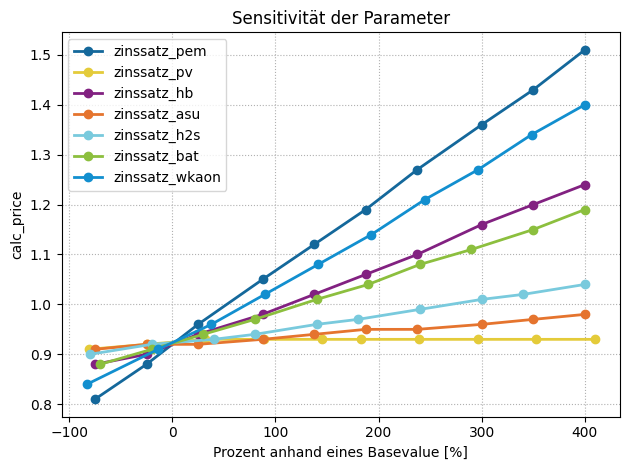

In [4]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_price", save_path="Bilder\sensitivitaet_calc_price.png")

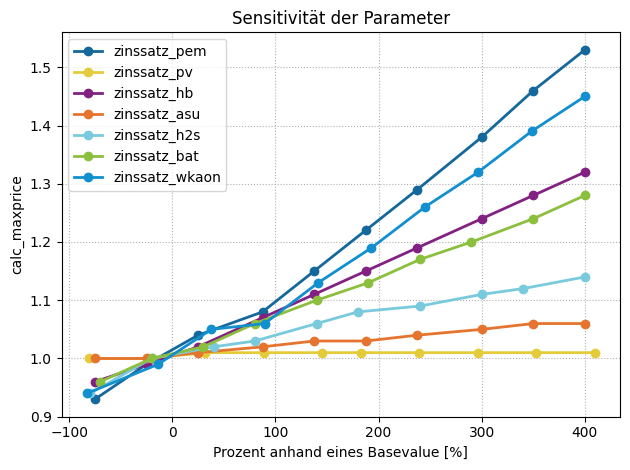

In [5]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_maxprice", save_path="Bilder\sensitivitaet_calc_maxprice.png")

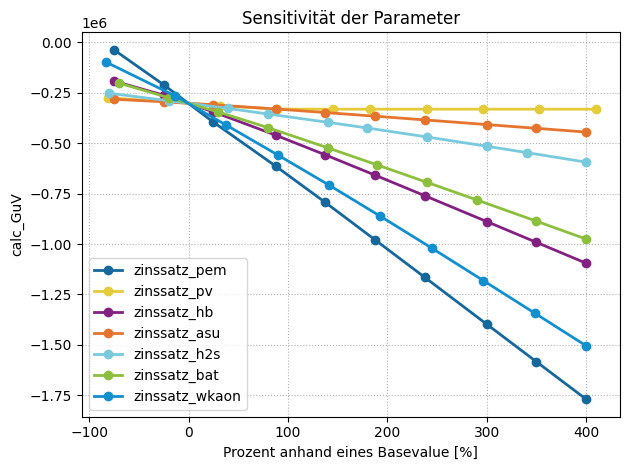

In [6]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_GuV", save_path="Bilder\sensitivitaet_calc_GuV.png")

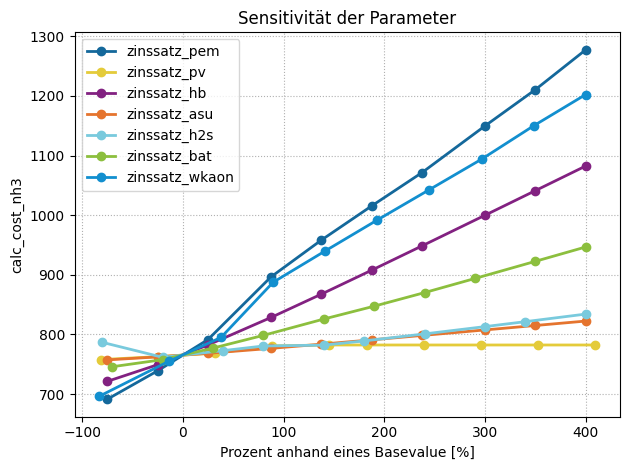

In [7]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_cost_nh3", save_path="Bilder\sensitivitaet_calc_cost_nh3.png")

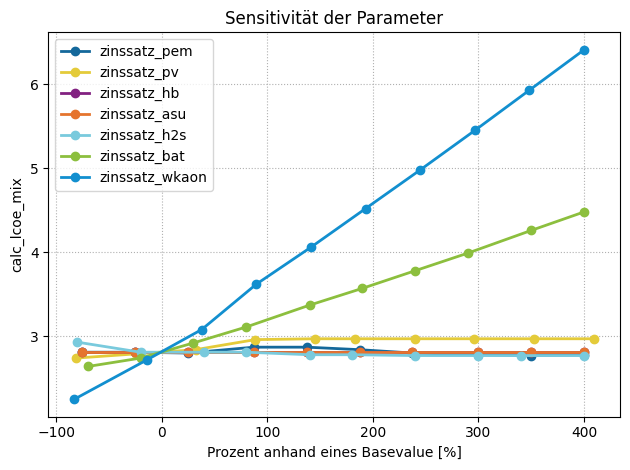

In [8]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_lcoe_mix", save_path="Bilder\sensitivitaet_calc_lcoe_mix.png")

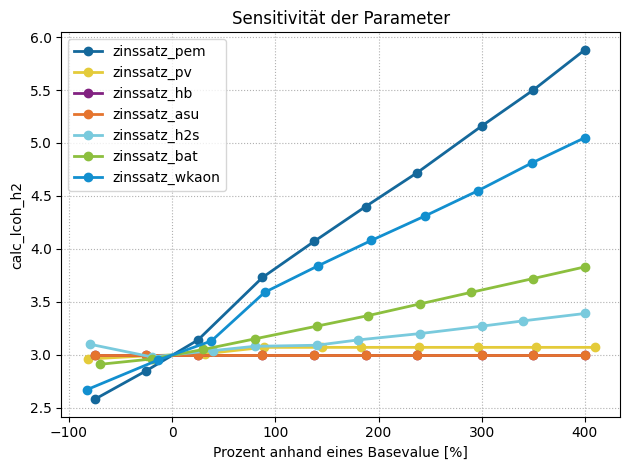

In [10]:
fig, ax = plot_sensitivity(df, df_mc, metric_name="calc_lcoh_h2", save_path="Bilder\sensitivitaet_calc_lcoh_h2.png")